In [ ]:
import numpy as np
def make_grid_codes_2D(scale, Xmax, nphase,  N_mod):
#Bicanski & Burgess (2019). modified and adapted for python.
  #Fmods = np.array([0.0014, 0.002, 0.0028, 0.004, 0.0055, 0.0077, 0.0108, 0.0151, 0.0211]) * 2 * np.pi
  ORIs = np.zeros(N_mod)
  N_mod_1d=N_mod
  NperMod = nphase
  res = 1
  Fmods = np.zeros([N_mod_1d])
  Fmods[0] = 0.0005

  #scales for each grid-module
  for k in np.arange(1,N_mod):
    Fmods[k] = (Fmods[k-1]*scale)
  Fmods = Fmods*2*np.pi

  #loop over image sizes
#Xs = [16, 49, 100, 169, 256, 361, 484, 625]

  #GC_interaction_info = np.zeros([len(Xs)])
  #random_interaction_info = np.zeros([len(Xs)])

  ctr=0
  #for Xmax in Xs:
  Ymax=Xmax
  nobs_x = Xmax + 1
  nobs_y = Ymax + 1
  n_freq = N_mod
  n = NperMod

 # 2D Grid
  X = np.arange(0, Xmax + 1, res)
  Y = np.arange(0, Ymax + 1, res)
  Xg, Yg = np.meshgrid(X, Y)

  Nx = Xg.size
  XY = np.column_stack((Xg.ravel(), Yg.ravel()))
  b0 = np.array([np.cos(0), np.sin(0)])
  b1 = np.array([np.cos(np.pi / 3), np.sin(np.pi / 3)])
  b2 = np.array([np.cos(2 * np.pi / 3), np.sin(2 * np.pi / 3)])

  # Placeholder for FAC (scaling factors)
  #FAC = np.array([0.0638, 0.0911, 0.128, 0.182, 0.26, 0.365, 0.515, 0.73, 1.0429])
  FAC = np.zeros([N_mod_1d])
  FAC[0]=0.001
  for k in np.arange(1,N_mod_1d):
    FAC[k] = (FAC[k-1]*scale)

  GC_FRmaps = np.zeros((len(X), len(Y), int(np.sqrt(NperMod) ** 2), N_mod))

  print(f'making grid cells of size [ {Xmax}, {Ymax}], with scaling of {round(scale,3)}x')
    # Loop through orientations and modules
  for i, ORI in enumerate(ORIs):
      F = Fmods[i]
      fac = FAC[i]
      R = np.array([[np.cos(ORI), -np.sin(ORI)], [np.sin(ORI), np.cos(ORI)]])

      x_off_base1 = 0
      y_off_base1 = fac * 1 / F
      x_off_base2 = fac * (1 / F) * np.cos(np.pi / 6)
      y_off_base2 = fac * (1 / F) * np.sin(np.pi / 6)

      Off_vec1 = R @ np.array([x_off_base1, y_off_base1])
      Off_vec2 = R @ np.array([x_off_base2, y_off_base2])

      for w in range(int(np.sqrt(NperMod))):
          for j in range(int(np.sqrt(NperMod))):
              Off = (j / 10) * Off_vec1 + (w / 10) * Off_vec2
              z0 = np.sum((R @ b0).reshape(1, -1) * (F * XY + Off), axis=1)
              z1 = np.sum((R @ b1).reshape(1, -1) * (F * XY + Off), axis=1)
              z2 = np.sum((R @ b2).reshape(1, -1) * (F * XY + Off), axis=1)

              FRmap = np.cos(z0) + np.cos(z1) + np.cos(z2)
              FRmap = FRmap / np.max(FRmap)
              #FRmap[FRmap < 0] = 0
              reshFRmap = FRmap.reshape(len(X), len(Y))
              reshFRmap = reshFRmap / np.max(reshFRmap)

              GC_FRmaps[:, :, int(w * np.sqrt(NperMod) + j), i] = reshFRmap

  nobs_x, nobs_y, n, n_freq = GC_FRmaps.shape
  mat_shaped = GC_FRmaps.reshape(nobs_x * nobs_y, n * n_freq)
  bin_mat = mat_shaped.T
  #binarize
  bin_mat[np.where(mat_shaped.T>0.5)]=1
  bin_mat[np.where(mat_shaped.T<=0.5)]=-1

  return GC_FRmaps, bin_mat

In [ ]:
#grid is x, y, #phases, #nfrequencies
grid, grid_flat = make_grid_codes_2D(1.65,200,10,9)

making grid cells of size [ 200, 200], with scaling of 1.65x


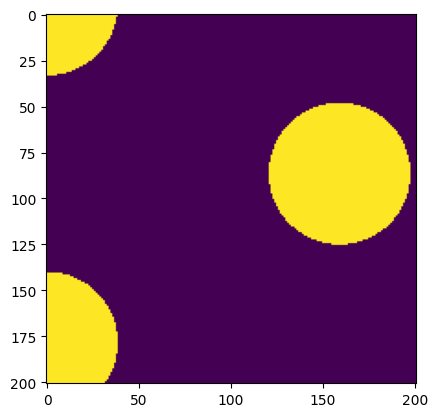

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(grid[:,:, 2,3])

In [ ]:
import torch

def sample_points_prob_dist(num_points, space_points, center_point, sigma=1.0):
    """
    Sample points from space_points with probability proportional
    to Gaussian decay of distance from center_point.
    """
    # Compute distances
    distances = torch.abs(space_points - center_point)

    # Compute unnormalized probabilities (Gaussian kernel)
    probs_unnorm = torch.exp(- (distances ** 2) / (2 * sigma ** 2))

    # Normalize to sum to 1
    probs = probs_unnorm / probs_unnorm.sum()

    # Sample indices according to probs
    indices = torch.multinomial(probs, num_points, replacement=True)

    return space_points[indices]

In [ ]:
import numpy as np

def make_grid_codes_1d(scale, Xmax,nphase, N_mod):
    """
    Generate 1D grid-like codes for positions 0..Xmax.

    Parameters:
    - scale: scaling factor between grid modules
    - Xmax: maximum position along 1D line
    - N_mod: number of grid modules (frequencies)
    - nphase: number of phases per module

    Returns:
    - GC_FRmaps: firing rate maps, shape [len(X), nphase, N_mod]
    - bin_mat: binarized code matrix, shape [nphase*N_mod, len(X)]
    """
    res = 1
    X = np.arange(0, Xmax + 1, res)  # spatial positions
    nobs_x = len(X)

    # Frequencies for each module
    Fmods = np.zeros(N_mod)
    Fmods[0] = 0.0014  # base frequency
    for k in range(1, N_mod):
        Fmods[k] = Fmods[k-1] * scale
    Fmods *= 2 * np.pi  # angular frequency

    # Scaling factors for phase offsets per module
    FAC = np.zeros(N_mod)
    FAC[0] = 0.0014
    for k in range(1, N_mod):
        FAC[k] = FAC[k-1] * scale

    # Prepare output arrays
    GC_FRmaps = np.zeros((nobs_x, nphase, N_mod))

    print(f'making 1D grid cells of size [{Xmax}], with scaling of {round(scale,3)}x')

    for i in range(N_mod):
        F = Fmods[i]
        fac = FAC[i]

        # Generate phase offsets along 1D
        for phase_idx in range(nphase):
            # Offset scaled by phase index; here evenly spaced phases over [0, 1)
            phase_offset = fac * (phase_idx / nphase) * (1 / F)

            # Compute grid cell response: cosine grating with phase offset
            z = F * X + phase_offset
            FRmap = np.cos(z)

            # Normalize to [0,1]
            FRmap = (FRmap - FRmap.min()) / (FRmap.max() - FRmap.min())
            GC_FRmaps[:, phase_idx, i] = FRmap

    # Reshape and binarize
    mat_shaped = GC_FRmaps.reshape(nobs_x, nphase * N_mod)  # shape: [nobs_x, nphase*N_mod]
    bin_mat = mat_shaped.T.copy()  # shape: [nphase*N_mod, nobs_x]
    bin_mat[bin_mat > 0.5] = 1
    bin_mat[bin_mat <= 0.5] = -1

    return GC_FRmaps, bin_mat

In [ ]:
#grid is x, y, #phases, #nfrequencies,
grid, grid_flat = make_grid_codes_1d(1.35,1000,100,9)

making 1D grid cells of size [1000], with scaling of 1.35x


In [ ]:
# --- build frequency & phase parameters ---
N_mod_1d = 13
Fmods = np.zeros(N_mod_1d)
Fmods[0] = 0.0014
for k in range(1, N_mod_1d):
    Fmods[k] = Fmods[k-1] * scale
Fmods *= 2 * np.pi

NperMod = 225
n_side  = int(np.sqrt(NperMod))
if n_side * n_side != NperMod:
    raise ValueError("NperMod must be a perfect square")
N_mod   = len(Fmods)

# spatial grid
X = np.arange(0, Xmax+1)
Y = X.copy()
Xg, Yg = np.meshgrid(X, Y)
XY      = np.column_stack((Xg.ravel(), Yg.ravel()))

# basis directions
b0 = np.array([1.0, 0.0])
b1 = np.array([np.cos(np.pi/3), np.sin(np.pi/3)])
b2 = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])

# scaling factors for offsets
FAC = np.zeros(N_mod_1d)
FAC[0] = 0.0638
for k in range(1, N_mod_1d):
    FAC[k] = FAC[k-1] * scale

# allocate binary codes: (X, Y, phases, modules)
GC_binary = np.zeros((len(X), len(Y), NperMod, N_mod), dtype=np.int8)

# --- fill with raw-thresholded codes ---
for i, F in enumerate(Fmods):
    fac = FAC[i]
    for w in range(n_side):
        for j in range(n_side):
            # random orientation per (module, phase)
            ORI = np.random.uniform(0, 2*np.pi)
            R   = np.array([[np.cos(ORI), -np.sin(ORI)],
                            [np.sin(ORI),  np.cos(ORI)]])

            # compute two offset vectors
            Off1 = R @ np.array([0, fac/F])
            Off2 = R @ np.array([fac*np.cos(np.pi/6)/F,
                                fac*np.sin(np.pi/6)/F])
            Off  = (j/n_side)*Off1 + (w/n_side)*Off2

            # raw sum of three cosines
            z0 = ((R @ b0).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
            z1 = ((R @ b1).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
            z2 = ((R @ b2).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
            raw = np.cos(z0) + np.cos(z1) + np.cos(z2)


                  #threshold at median
                  #m = np.median(raw)
                  #bm = (raw >= m).astype(int)
                  #GC_binary[:, :, w*n_side+j, i] = bm.reshape(len(X), len(Y))

                  # threshold at zero to get balanced binary map
            bm = (raw >= 0).astype(np.int8)
            GC_binary[:, :, w*n_side+j, i] = bm.reshape(len(X), len(Y))

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(GC_binary[:,:, 10,12])

IndexError: index 12 is out of bounds for axis 3 with size 12

In [ ]:

#Generalization/Identification Tradeoff as a Function of Distribution Alignment

import torch

def transition_distribution_2d(space_points, center_points, sigma, alpha):
    """
    space_points: [M, 2]
    center_points: [num_trials, 2]
    sigma: float
    alpha: float

    Returns: probs of shape [num_trials, M]
    """
    num_trials = center_points.size(0)
    M = space_points.size(0)

    sp_exp = space_points.unsqueeze(0)         # [1, M, 2]
    cp_exp = center_points.unsqueeze(1)        # [num_trials, 1, 2]

    dists = torch.norm(sp_exp - cp_exp, dim=2) # [num_trials, M]

    uniform = torch.ones(M, device=space_points.device) / M
    gauss_unnorm = torch.exp(- (dists ** 2) / (2 * sigma ** 2))
    gauss = gauss_unnorm / gauss_unnorm.sum(dim=1, keepdim=True)

    probs = (1 - alpha) * uniform + alpha * gauss
    probs = probs / probs.sum(dim=1, keepdim=True)
    return probs


        # --- Extract grid codes for hamming distance calculations ---
        # Convert gen_points and sampled_pairs to grid indices
def points_to_grid_indices(pts):
  # Round and clamp indices to grid bounds
  x = pts[:, 0].round().long().clamp(0, Xmax)
  y = pts[:, 1].round().long().clamp(0, Xmax)
  return x, y

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#size of space (XmaxXXmax)
Xmax = 200
num_trials = 10000
sigma = 0.1
N_mod = 9
nphase = 10
nIT = 10000

scales = torch.arange(0.05, 5, 0.1, device=device)
alphas = torch.linspace(0, 0, 1, device=device)  # 0 to 1
#alphas = [0,]
# Create 2D grid points for sampling
grid_points_1d = torch.linspace(0, Xmax, steps=100, device=device)
X_grid, Y_grid = torch.meshgrid(grid_points_1d, grid_points_1d, indexing='ij')
space_points = torch.stack([X_grid.reshape(-1), Y_grid.reshape(-1)], dim=1)  # [10000, 2]

scale_perf = []
id_scale_perf = []

generalization = torch.zeros(len(alphas), len(scales), device=device)
identification = torch.zeros(len(alphas), len(scales), device=device)

def hamming_distance_batch(a, b):
    return (a != b).float().mean(dim=1)

# robust hamming distance that tolerates numpy or torch inputs
def hamming_distance_batch2(a, b, device=None):
    # infer device if not provided
    if device is None:
        if torch.is_tensor(a):
            device = a.device
        elif torch.is_tensor(b):
            device = b.device
        else:
            device = torch.device("cpu")

    if not torch.is_tensor(a):
        a = torch.as_tensor(a, device=device)
    else:
        a = a.to(device)

    if not torch.is_tensor(b):
        b = torch.as_tensor(b, device=device)
    else:
        b = b.to(device)

    return (a != b).to(torch.float32).mean(dim=1)

alpha_ctr = -1
for alpha in alphas:
    alpha_ctr+=1
    scale_ctr=-1
    for scale in scales:
        scale_ctr+=1
        #grid, _ = make_grid_codes_2D(scale.item(), Xmax, N_mod, nphase)
      # --- build frequency & phase parameters ---
        N_mod_1d = 9
        Fmods = np.zeros(N_mod_1d)
        Fmods[0] = 0.0014
        for k in range(1, N_mod_1d):
            Fmods[k] = Fmods[k-1] * scale
        Fmods *= 2 * np.pi

        NperMod = 225
        n_side  = int(np.sqrt(NperMod))
        if n_side * n_side != NperMod:
            raise ValueError("NperMod must be a perfect square")
        N_mod   = len(Fmods)

        # spatial grid
        X = np.arange(0, Xmax+1)
        Y = X.copy()
        Xg, Yg = np.meshgrid(X, Y)
        XY      = np.column_stack((Xg.ravel(), Yg.ravel()))

        # basis directions
        b0 = np.array([1.0, 0.0])
        b1 = np.array([np.cos(np.pi/3), np.sin(np.pi/3)])
        b2 = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])

        # scaling factors for offsets
        FAC = np.zeros(N_mod_1d)
        FAC[0] = 0.0638
        for k in range(1, N_mod_1d):
            FAC[k] = FAC[k-1] * scale

        # allocate binary codes: (X, Y, phases, modules)
        GC_binary = np.zeros((len(X), len(Y), NperMod, N_mod), dtype=np.int8)

        # --- fill with raw-thresholded codes ---
        for i, F in enumerate(Fmods):
            fac = FAC[i]
            for w in range(n_side):
                for j in range(n_side):
                    # random orientation per (module, phase)
                    ORI = np.random.uniform(0, 2*np.pi)
                    R   = np.array([[np.cos(ORI), -np.sin(ORI)],
                                    [np.sin(ORI),  np.cos(ORI)]])

                    # compute two offset vectors
                    Off1 = R @ np.array([0, fac/F])
                    Off2 = R @ np.array([fac*np.cos(np.pi/6)/F,
                                        fac*np.sin(np.pi/6)/F])
                    Off  = (j/n_side)*Off1 + (w/n_side)*Off2

                    # raw sum of three cosines
                    z0 = ((R @ b0).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
                    z1 = ((R @ b1).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
                    z2 = ((R @ b2).reshape(1,-1) * (F*XY + Off)).sum(axis=1)
                    raw = np.cos(z0) + np.cos(z1) + np.cos(z2)


                          #threshold at median
                          #m = np.median(raw)
                          #bm = (raw >= m).astype(int)
                          #GC_binary[:, :, w*n_side+j, i] = bm.reshape(len(X), len(Y))

                          # threshold at zero to get balanced binary map
                    bm = (raw >= 0).astype(np.int8)
                    GC_binary[:, :, w*n_side+j, i] = bm.reshape(len(X), len(Y))

        grid = GC_binary.reshape((Xmax+1)*(Xmax+1), N_mod*NperMod)

                    # Sample two random points per trial uniformly from space_points indices
        M = space_points.size(0)
        sampled_pair_indices = torch.randint(0, M, (num_trials, 2), device=device)  # [num_trials, 2]
        sampled_pairs = space_points[sampled_pair_indices]  # [num_trials, 2, 2]

                    # --- Identification task ---
                    # Randomly select target index (0 or 1) for each trial
        target_choice = torch.randint(0, 2, (num_trials,), device=device)
        target_i = sampled_pairs[torch.arange(num_trials), target_choice]  # [num_trials, 2]

                    # Compute distance of target to both points in the pair
        dist_id = torch.norm(target_i.unsqueeze(1) - sampled_pairs, dim=2)  # [num_trials, 2]
        id_closest = torch.argmin(dist_id, dim=1)

                    # Correct if closest point is the target itself
        id_correct = (id_closest == target_choice).float()

                    # --- Generalization task ---
                    # Sample generalization point from distribution interpolating uniform <-> Gaussian near one of the pair points

                    # Randomly choose which point to center the Gaussian on
        gaussian_centers = sampled_pairs[torch.arange(num_trials), torch.randint(0, 2, (num_trials,), device=device)]  # [num_trials, 2]

                    # Compute probability distributions for generalization points
        gen_probs = transition_distribution_2d(space_points, gaussian_centers, sigma, alpha.item())  # [num_trials, M]

                    # Sample one generalization point per trial
        gen_indices = torch.multinomial(gen_probs, 1).squeeze(1)  # [num_trials]
        gen_points = space_points[gen_indices]  # [num_trials, 2]

                    # Compute distance from generalization point to each point in sampled pair
        dist_gen = torch.norm(gen_points.unsqueeze(1) - sampled_pairs, dim=2)  # [num_trials, 2]
        gen_closest = torch.argmin(dist_gen, dim=1)

                    # Determine which point in pair is "correct" target for generalization:
                    # (You can choose e.g., always point 0 as "correct" or use other logic)
                    # For this example, we take point 0 as correct
        gen_correct = (gen_closest == 0).float()

                # make sure grid is a torch tensor on GPU
        # grid = grid.to(device)  # wherever you set device

        # ensure indices are torch.LongTensor on the SAME device as grid
        gen_x, gen_y = points_to_grid_indices(gen_points)
        p0_x,  p0_y  = points_to_grid_indices(sampled_pairs[:, 0, :])
        p1_x,  p1_y  = points_to_grid_indices(sampled_pairs[:, 1, :])

        gen_x = torch.as_tensor(gen_x, device=grid.device, dtype=torch.long)
        gen_y = torch.as_tensor(gen_y, device=grid.device, dtype=torch.long)
        p0_x  = torch.as_tensor(p0_x,  device=grid.device, dtype=torch.long)
        p0_y  = torch.as_tensor(p0_y,  device=grid.device, dtype=torch.long)
        p1_x  = torch.as_tensor(p1_x,  device=grid.device, dtype=torch.long)
        p1_y  = torch.as_tensor(p1_y,  device=grid.device, dtype=torch.long)

        gen_codes = grid[gen_x, gen_y]
        p0_codes  = grid[p0_x,  p0_y]
        p1_codes  = grid[p1_x,  p1_y]

        # If you need to reshape, prefer reshape() or make contiguous before view()
        gen_codes = gen_codes.reshape(num_trials, -1)  # or .contiguous().view(num_trials, -1)
        p0_codes  = p0_codes.reshape(num_trials, -1)
        p1_codes  = p1_codes.reshape(num_trials, -1)

        # gen_x, gen_y = points_to_grid_indices(gen_points)
        # p0_x, p0_y = points_to_grid_indices(sampled_pairs[:, 0, :])
        # p1_x, p1_y = points_to_grid_indices(sampled_pairs[:, 1, :])

        # gen_codes = grid[gen_x, gen_y].view(num_trials, -1)
        # p0_codes = grid[p0_x, p0_y].view(num_trials, -1)
        # p1_codes = grid[p1_x, p1_y].view(num_trials, -1)

        noise_level = 0.1

                    # Hamming distances to gen_point
        dist_a = hamming_distance_batch2(p0_codes, gen_codes) + torch.randn(num_trials, device=device) * noise_level
        dist_b = hamming_distance_batch2(p1_codes, gen_codes) + torch.randn(num_trials, device=device) * noise_level

        cond1 = (dist_a < dist_b) & (gen_closest == 0)
        cond2 = (dist_a > dist_b) & (gen_closest == 1)
        cond3 = (dist_a == dist_b) & (torch.randn(num_trials, device=device) > 0)
        gen_perf = (cond1 | cond2 | cond3).float()

                    # Hamming distances for ID (using target point)
        dist_id_a = hamming_distance_batch2(p0_codes, p0_codes) + torch.randn(num_trials, device=device) * noise_level
        dist_id_b = hamming_distance_batch2(p1_codes, p0_codes) + torch.randn(num_trials, device=device) * noise_level

        cond_id1 = (dist_id_a < dist_id_b)
        cond_id3 = (dist_id_a == dist_id_b) & (torch.randn(num_trials, device=device) > 0)
        id_perf_final = (cond_id1 | cond_id3).float()

        print(f"Alpha={alpha.item():.2f}, Scale={scale.item():.2f}, Gen Accuracy={gen_perf.mean().item():.4f}, ID Accuracy={id_perf_final.mean().item():.4f}")

        scale_perf.append(gen_perf.mean().item())
        id_scale_perf.append(id_perf_final.mean().item())

        generalization[alpha_ctr,scale_ctr] = gen_perf.mean().item()
        identification[alpha_ctr,scale_ctr] = id_perf_final.mean().item()

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
# Generalization/Identification Tradeoff as a Function of Distribution Alignment

import numpy as np
import torch

# ----------------------------
# Device
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------------------
# Helpers
# ----------------------------
def transition_distribution_2d(space_points, center_points, sigma, alpha):
    """
    space_points: [M, 2]  (torch, device)
    center_points: [num_trials, 2] (torch, device)
    sigma: float
    alpha: float in [0,1]
    Returns: probs of shape [num_trials, M] (torch, device)
    """
    num_trials = center_points.size(0)
    M = space_points.size(0)

    sp_exp = space_points.unsqueeze(0)      # [1, M, 2]
    cp_exp = center_points.unsqueeze(1)     # [num_trials, 1, 2]

    dists = torch.norm(sp_exp - cp_exp, dim=2)  # [num_trials, M]

    # Broadcast uniform across trials
    uniform = torch.ones(M, device=space_points.device) / M               # [M]
    gauss_unnorm = torch.exp(-(dists ** 2) / (2 * sigma ** 2))            # [num_trials, M]
    gauss = gauss_unnorm / gauss_unnorm.sum(dim=1, keepdim=True)          # [num_trials, M]

    probs = (1 - alpha) * uniform + alpha * gauss                          # [num_trials, M] via broadcast
    probs = probs / probs.sum(dim=1, keepdim=True)
    return probs

def points_to_grid_indices(pts, Xmax):
    """
    pts: [N, 2] torch on device
    Returns integer grid indices (x, y) clamped to [0, Xmax].
    """
    x = pts[:, 0].round().long().clamp(0, Xmax)
    y = pts[:, 1].round().long().clamp(0, Xmax)
    return x, y

def hamming_distance_batch(a, b):
    """
    a, b: torch tensors [B, D], same device, comparable dtype
    Returns mean Hamming distance across features for each batch item: [B]
    """
    return (a != b).to(torch.float32).mean(dim=1)

# ----------------------------
# Parameters
# ----------------------------
Xmax        = 100
num_trials  = 10000
sigma       = 0.1
N_mod_1d    = 13
nphase      = 10
nIT         = 10000

# sweep
scales = torch.arange(0.05, 5.0, 0.1, device=device)
#alphas = torch.linspace(0.0, 0.0, 1, device=device)  # adjust as needed
alphas = torch.linspace(0.0, 1, 10, device=device)  # adjust as needed
alphas = (0.5,)
# 2D space points for sampling (torch, device)
grid_points_1d = torch.linspace(0, Xmax, steps=100, device=device)
X_grid, Y_grid = torch.meshgrid(grid_points_1d, grid_points_1d, indexing='ij')
space_points = torch.stack([X_grid.reshape(-1), Y_grid.reshape(-1)], dim=1)  # [10000, 2]
M = space_points.size(0)

# Results (torch, device)
generalization = torch.zeros(len(alphas), len(scales), device=device)
identification = torch.zeros(len(alphas), len(scales), device=device)

# ----------------------------
# Main loops
# ----------------------------
noise_level = 0.4
alpha_ctr = -1

for alpha in alphas:
    alpha_ctr += 1
    scale_ctr = -1

    for scale in scales:
        scale_ctr += 1

        # ----------------------------
        # Build grid codes (NumPy) → convert once to Torch(device)
        # ----------------------------
        scale_val = float(scale)  # use pure float in NumPy math
        Fmods = np.zeros(N_mod_1d, dtype=np.float64)
        Fmods[0] = 0.0014
        for k in range(1, N_mod_1d):
            Fmods[k] = Fmods[k-1] * scale_val
        Fmods *= 2 * np.pi

        NperMod = 16
        n_side  = int(np.sqrt(NperMod))
        if n_side * n_side != NperMod:
            raise ValueError("NperMod must be a perfect square")

        # spatial grid (NumPy)
        X = np.arange(0, Xmax+1)
        Y = X.copy()
        Xg, Yg = np.meshgrid(X, Y)
        XY = np.column_stack((Xg.ravel(), Yg.ravel()))  # [(Xmax+1)^2, 2]

        # basis directions
        b0 = np.array([1.0, 0.0])
        b1 = np.array([np.cos(np.pi/3),  np.sin(np.pi/3)])
        b2 = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])

        # scaling factors for offsets
        FAC = np.zeros(N_mod_1d, dtype=np.float64)
        FAC[0] = 0.06
        for k in range(1, N_mod_1d):
            FAC[k] = FAC[k-1] * scale_val

        # allocate binary codes: (X, Y, phases, modules)
        GC_binary = np.zeros((Xmax+1, Xmax+1, NperMod, N_mod_1d), dtype=np.int8)

        # fill codes
        for i_mod, F in enumerate(Fmods):
            fac = FAC[i_mod]
            for w in range(n_side):
                for j in range(n_side):
                    # random orientation per (module, phase)
                    ORI = np.random.uniform(0, 2*np.pi)
                    R = np.array([[np.cos(ORI), -np.sin(ORI)],
                                  [np.sin(ORI),  np.cos(ORI)]])

                    # two offset vectors
                    Off1 = R @ np.array([0, fac / F])
                    Off2 = R @ np.array([fac * np.cos(np.pi/6) / F,
                                         fac * np.sin(np.pi/6) / F])
                    Off  = (j / n_side) * Off1 + (w / n_side) * Off2

                    # raw sum of three cosines
                    z0 = ((R @ b0).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                    z1 = ((R @ b1).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                    z2 = ((R @ b2).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                    raw = np.cos(z0) + np.cos(z1) + np.cos(z2)

                    # threshold at zero → balanced binary
                    bm = (raw >= 0).astype(np.int8)  # [ (Xmax+1)^2 ]
                    GC_binary[:, :, w*n_side + j, i_mod] = bm.reshape(Xmax+1, Xmax+1)

        # Convert to Torch on the chosen device and flatten feature dims only
        # Final shape: [Xmax+1, Xmax+1, N_mod_1d*NperMod]
        grid = torch.from_numpy(GC_binary).to(device=device)  # int8 on device
        grid = grid.view(Xmax+1, Xmax+1, -1)                  # [Hx, Hy, nfeat]

        # ----------------------------
        # Sample pairs and generalization points (Torch, device)
        # ----------------------------
        sampled_pair_indices = torch.randint(0, M, (num_trials, 2), device=device)   # [num_trials, 2]
        sampled_pairs = space_points[sampled_pair_indices]                            # [num_trials, 2, 2]

        # --- Identification task ---
        target_choice = torch.randint(0, 2, (num_trials,), device=device)            # [num_trials]
        target_i = sampled_pairs[torch.arange(num_trials, device=device), target_choice]  # [num_trials, 2]
        dist_id = torch.norm(target_i.unsqueeze(1) - sampled_pairs, dim=2)           # [num_trials, 2]
        id_closest = torch.argmin(dist_id, dim=1)
        id_correct = (id_closest == target_choice).float()

        # --- Generalization task ---
        gaussian_centers = sampled_pairs[torch.arange(num_trials, device=device),
                                         torch.randint(0, 2, (num_trials,), device=device)]  # [num_trials, 2]
        gen_probs = transition_distribution_2d(space_points, gaussian_centers, sigma, float(alpha))  # [num_trials, M]
        gen_indices = torch.multinomial(gen_probs, 1).squeeze(1)                                   # [num_trials]
        gen_points = space_points[gen_indices]                                                     # [num_trials, 2]

        dist_gen = torch.norm(gen_points.unsqueeze(1) - sampled_pairs, dim=2)  # [num_trials, 2]
        gen_closest = torch.argmin(dist_gen, dim=1)
        gen_correct = (gen_closest == 0).float()  # example rule

        # ----------------------------
        # Extract grid codes using Torch indices (same device)
        # grid shape: [Xmax+1, Xmax+1, nfeat]
        # ----------------------------
        gen_x, gen_y = points_to_grid_indices(gen_points, Xmax)
        p0_x,  p0_y  = points_to_grid_indices(sampled_pairs[:, 0, :], Xmax)
        p1_x,  p1_y  = points_to_grid_indices(sampled_pairs[:, 1, :], Xmax)

        gen_codes = grid[gen_x, gen_y]                 # [num_trials, nfeat]
        p0_codes  = grid[p0_x,  p0_y]                  # [num_trials, nfeat]
        p1_codes  = grid[p1_x,  p1_y]                  # [num_trials, nfeat]

        # ----------------------------
        # Hamming distances (Torch, device)
        # ----------------------------
        noise_a = torch.randn(num_trials, device=device) * noise_level
        noise_b = torch.randn(num_trials, device=device) * noise_level

        dist_a = hamming_distance_batch(p0_codes, gen_codes) + noise_a
        dist_b = hamming_distance_batch(p1_codes, gen_codes) + noise_b

        cond1 = (dist_a <  dist_b) & (gen_closest == 0)
        cond2 = (dist_a >  dist_b) & (gen_closest == 1)
        cond3 = (dist_a == dist_b) & (torch.randn(num_trials, device=device) > 0)
        gen_perf = (cond1 | cond2 | cond3).float()

        # Identification distances (using p0 as target)
        noise_id_a = torch.randn(num_trials, device=device) * noise_level
        noise_id_b = torch.randn(num_trials, device=device) * noise_level
        dist_id_a = hamming_distance_batch(p0_codes, p0_codes) + noise_id_a
        dist_id_b = hamming_distance_batch(p1_codes, p0_codes) + noise_id_b

        cond_id1 = (dist_id_a <  dist_id_b)
        cond_id3 = (dist_id_a == dist_id_b) & (torch.randn(num_trials, device=device) > 0)
        id_perf_final = (cond_id1 | cond_id3).float()

        # ----------------------------
        # Log & store
        # ----------------------------
        print(f"Alpha={float(alpha):.2f} | Scale={float(scale):.2f} | "
              f"Gen Acc={gen_perf.mean().item():.4f} | ID Acc={id_perf_final.mean().item():.4f}")

        generalization[alpha_ctr, scale_ctr] = gen_perf.mean()
        identification[alpha_ctr, scale_ctr] = id_perf_final.mean()

Alpha=0.50 | Scale=0.05 | Gen Acc=0.5034 | ID Acc=0.5001
Alpha=0.50 | Scale=0.15 | Gen Acc=0.5135 | ID Acc=0.5017
Alpha=0.50 | Scale=0.25 | Gen Acc=0.5141 | ID Acc=0.5039
Alpha=0.50 | Scale=0.35 | Gen Acc=0.5110 | ID Acc=0.5093
Alpha=0.50 | Scale=0.45 | Gen Acc=0.5093 | ID Acc=0.5110
Alpha=0.50 | Scale=0.55 | Gen Acc=0.5030 | ID Acc=0.5054
Alpha=0.50 | Scale=0.65 | Gen Acc=0.5080 | ID Acc=0.5132
Alpha=0.50 | Scale=0.75 | Gen Acc=0.5107 | ID Acc=0.5007
Alpha=0.50 | Scale=0.85 | Gen Acc=0.5235 | ID Acc=0.5293
Alpha=0.50 | Scale=0.95 | Gen Acc=0.5404 | ID Acc=0.5474
Alpha=0.50 | Scale=1.05 | Gen Acc=0.5840 | ID Acc=0.6015
Alpha=0.50 | Scale=1.15 | Gen Acc=0.6092 | ID Acc=0.6552
Alpha=0.50 | Scale=1.25 | Gen Acc=0.6468 | ID Acc=0.7175
Alpha=0.50 | Scale=1.35 | Gen Acc=0.6462 | ID Acc=0.7409
Alpha=0.50 | Scale=1.45 | Gen Acc=0.6409 | ID Acc=0.7437
Alpha=0.50 | Scale=1.55 | Gen Acc=0.6528 | ID Acc=0.7673
Alpha=0.50 | Scale=1.65 | Gen Acc=0.6464 | ID Acc=0.7692
Alpha=0.50 | Scale=1.75 | Gen A

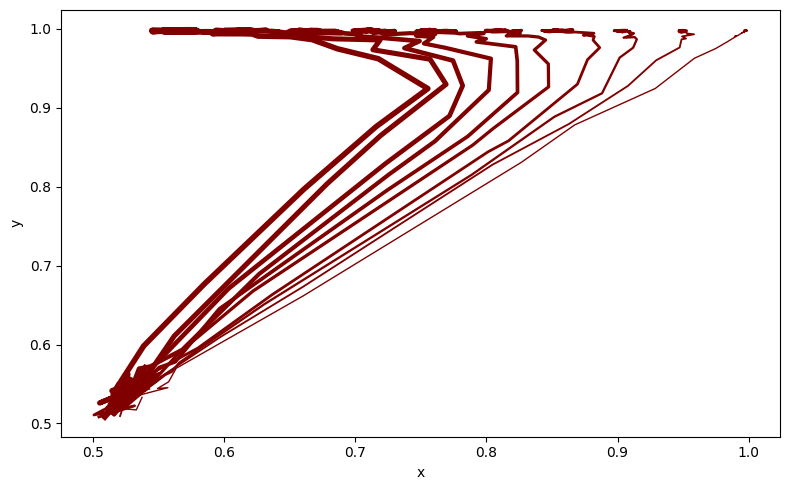

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# generalization, identification are 2D (rows × cols)
x = generalization.cpu().numpy().T
y = identification.cpu().numpy().T

n_cols = x.shape[1]

min_lw, max_lw = 1.0, 4.0
den = max(1, n_cols - 1)

plt.figure(figsize=(8,5))

# plot thickest first so thin lines don't get buried
for j in range(n_cols):
    lw = max_lw - (max_lw - min_lw) * (j / den)  # j=0 → thick; j=last → thin
    plt.plot(x[:, j], y[:, j], color='maroon', lw=lw, alpha=1, zorder=11-j)

plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

In [ ]:
generalization.shape

torch.Size([10, 50])

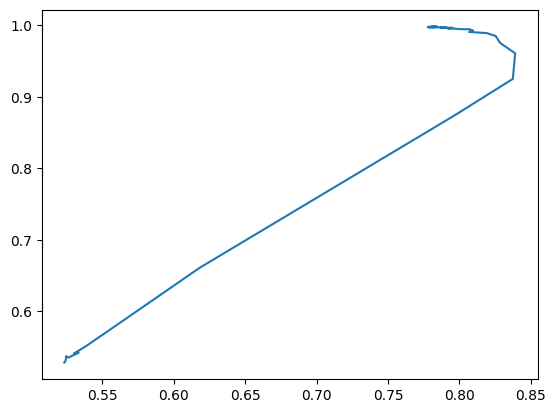

In [ ]:
plt.plot(torch.mean(generalization.cpu(),0), torch.mean(identification.cpu(),0))

In [ ]:
m = torch.mean(generalization.cpu(),0)

In [ ]:
m[13]
scales[13]

tensor(1.3500, device='cuda:0')

In [ ]:
plt.plot(g.T[:,25], i.T[:,25])

NameError: name 'g' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_alphas = len(alphas)
num_scales = len(scales)

gen_acc_matrix = np.array(scale_perf).reshape(num_alphas, num_scales)
id_acc_matrix = np.array(id_scale_perf).reshape(num_alphas, num_scales)

plt.figure(figsize=(8, 6))

# Flatten matrices for scatter plot
gen_acc_flat = gen_acc_matrix.flatten()
id_acc_flat = id_acc_matrix.flatten()

# Repeat scales and alphas to match flattened arrays
scales_flat = np.repeat(scales.cpu().numpy(), num_alphas)
alphas_flat = np.tile(alphas.cpu().numpy(), num_scales)

# Create scatter plot
scatter = plt.scatter(gen_acc_flat, id_acc_flat, c=scales_flat, s=50 + 200*alphas_flat,
                      cmap='viridis', alpha=0.7, edgecolors='k')

plt.xlabel('Generalization Accuracy')
plt.ylabel('Identification Accuracy')
cbar = plt.colorbar(scatter)
cbar.set_label('Grid Scale')

# # Add a legend for marker sizes corresponding to alpha
# for alpha_val in alphas.cpu():
#     plt.scatter([], [], s=50 + 200*alpha_val, c='gray', alpha=0.7,
#                 label=f'Alpha={alpha_val:.1f}')
# plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title='Alpha')

plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'alphas' is not defined

In [ ]:
identification.shape

torch.Size([50, 40])

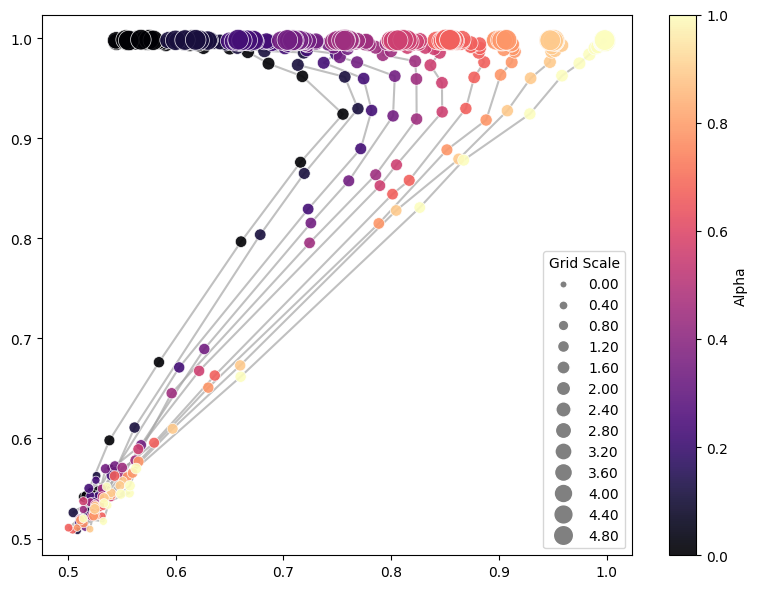

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# tensors -> numpy
gen = generalization.detach().cpu().numpy()      # [num_alphas, num_scales]
iden = identification.detach().cpu().numpy()     # [num_alphas, num_scales]
a_np = alphas.detach().cpu().numpy()             # [num_alphas]
s_np = scales.detach().cpu().numpy()             # [num_scales]

num_a, num_s = gen.shape

# sort scales so lines connect left→right
s_order   = np.argsort(s_np)
s_sorted  = s_np[s_order]

# ----- sizes from scale (use np.ptp) -----
rng = np.ptp(s_sorted) + 1e-12
s_norm = (s_sorted - s_sorted.min()) / rng
size_min, size_max = 30.0, 220.0  # scatter uses area (pts^2)
size_per_scale = size_min + (size_max - size_min) * s_norm   # [num_scales]

# helper for legend: map any scale -> size consistently
def scale_to_size(s):
    return size_min + (size_max - size_min) * ((s - s_sorted.min()) / (np.ptp(s_sorted) + 1e-12))

# build per-point arrays in the same (alpha, scale) order used for plotting
X = gen[:, s_order].ravel()
Y = iden[:, s_order].ravel()
sizes  = np.tile(size_per_scale, num_a)          # size = scale
colors = np.repeat(a_np, num_s)                  # color = alpha

# color mapping for alpha
norm_a = Normalize(vmin=a_np.min(), vmax=a_np.max())
#cmap   = plt.cm.viridis
cmap = plt.cm.magma

plt.figure(figsize=(8, 6))

# 1) gray connector lines per alpha (across scales)
for i in range(num_a):
    xi = gen[i, s_order]
    yi = iden[i, s_order]
    if xi.size >= 2:
        plt.plot(xi, yi, color='0.65', lw=1.5, alpha=0.7, zorder=1)

# 2) scatter: size = scale, color = alpha
sc = plt.scatter(
    X, Y,
    s=sizes,
    c=colors,
    cmap=cmap, norm=norm_a,
    alpha=0.9,
    edgecolors='white', linewidths=0.5,
    zorder=2
)

# plt.xlabel('Generalization Accuracy')
# plt.ylabel('Identification Accuracy')
# plt.title('ID vs Gen Accuracy\n(Size = Scale, Color = Alpha)')

# colorbar for alpha
cbar = plt.colorbar(sc)
cbar.set_label('Alpha')

# ---- richer size legend for scale (more entries) ----
n_legend = min(10, len(s_sorted))  # change to 6/7 if you want more
legend_scales = (0, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8 )
n_legend = len(legend_scales)
#legend_scales = np.linspace(s_sorted.min(), s_sorted.max(), n_legend
#legend_scales = np.linspace(s_sorted.min(), s_sorted.max(), n_legend)
handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markersize=np.sqrt(scale_to_size(s)),
           markerfacecolor='gray', markeredgecolor='white',
           label=f'{s:.2f}')
    for s in legend_scales
]
plt.legend(handles=handles, title='Grid Scale', loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

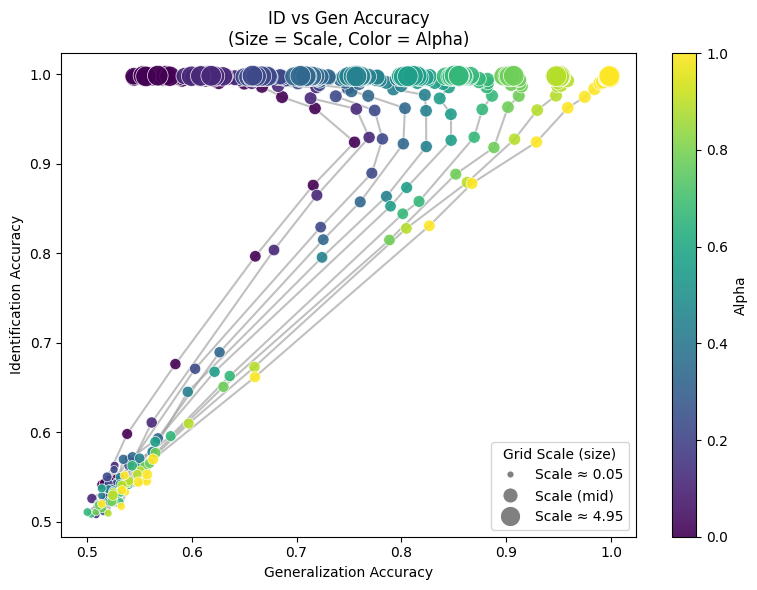

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# tensors -> numpy
gen = generalization.detach().cpu().numpy()      # shape: [num_alphas, num_scales]
iden = identification.detach().cpu().numpy()     # shape: [num_alphas, num_scales]
a_np = alphas.detach().cpu().numpy()             # [num_alphas]
s_np = scales.detach().cpu().numpy()             # [num_scales]

num_a, num_s = gen.shape

# sort scales so lines connect left→right
s_order = np.argsort(s_np)
s_sorted = s_np[s_order]

# ----- sizes from scale -----
s_norm = (s_sorted - s_sorted.min()) / (np.ptp(s_sorted + 1e-12))
size_min, size_max = 30.0, 220.0
size_per_scale = size_min + (size_max - size_min) * s_norm    # [num_scales]

# build per-point arrays in the same (alpha, scale) order used for plotting
X = gen[:, s_order].ravel()
Y = iden[:, s_order].ravel()
sizes = np.tile(size_per_scale, num_a)                         # repeat across alphas
colors = np.repeat(a_np, num_s)                                # alpha per row, flattened

# color mapping for alpha
norm_a = Normalize(vmin=a_np.min(), vmax=a_np.max())
cmap = plt.cm.viridis

plt.figure(figsize=(8, 6))

# 1) gray connector lines per alpha (across scales)
for i in range(num_a):
    xi = gen[i, s_order]
    yi = iden[i, s_order]
    if xi.size >= 2:
        plt.plot(xi, yi, color='0.65', lw=1.5, alpha=0.7, zorder=1)

# 2) scatter: size = scale, color = alpha
sc = plt.scatter(
    X, Y,
    s=sizes,
    c=colors,
    cmap=cmap, norm=norm_a,
    alpha=0.9,
    edgecolors='white', linewidths=0.5,
    zorder=2
)

plt.xlabel('Generalization Accuracy')
plt.ylabel('Identification Accuracy')

# colorbar for alpha
cbar = plt.colorbar(sc)
cbar.set_label('Alpha')

# simple size legend for scale (min/mid/max)
handles = [
    Line2D([0],[0], marker='o', linestyle='None', markersize=np.sqrt(size_min),
           markerfacecolor='gray', markeredgecolor='white', label=f'Scale ≈ {s_sorted.min():.2f}'),
    Line2D([0],[0], marker='o', linestyle='None', markersize=np.sqrt((size_min+size_max)/2),
           markerfacecolor='gray', markeredgecolor='white', label='Scale (mid)'),
    Line2D([0],[0], marker='o', linestyle='None', markersize=np.sqrt(size_max),
           markerfacecolor='gray', markeredgecolor='white', label=f'Scale ≈ {s_sorted.max():.2f}')
]
plt.legend(handles=handles, title='Grid Scale', loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


In [ ]:
scales

tensor([0.0500, 0.1500, 0.2500, 0.3500, 0.4500, 0.5500, 0.6500, 0.7500, 0.8500,
        0.9500, 1.0500, 1.1500, 1.2500, 1.3500, 1.4500, 1.5500, 1.6500, 1.7500,
        1.8500, 1.9500, 2.0500, 2.1500, 2.2500, 2.3500, 2.4500, 2.5500, 2.6500,
        2.7500, 2.8500, 2.9500, 3.0500, 3.1500, 3.2500, 3.3500, 3.4500, 3.5500,
        3.6500, 3.7500, 3.8500, 3.9500, 4.0500, 4.1500, 4.2500, 4.3500, 4.4500,
        4.5500, 4.6500, 4.7500, 4.8500, 4.9500], device='cuda:0')

ValueError: s must be a scalar, or float array-like with the same size as x and y

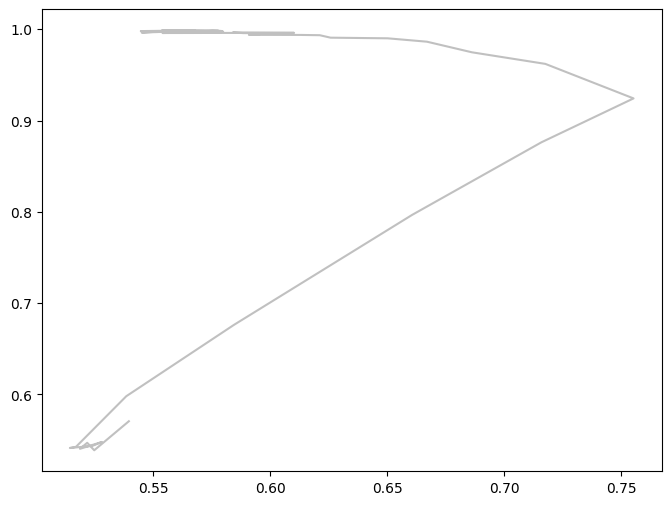

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# tensors -> numpy
gen = generalization.detach().cpu().numpy()      # [num_alphas, num_scales]
iden = identification.detach().cpu().numpy()     # [num_alphas, num_scales]
a_np = alphas.detach().cpu().numpy()             # [num_alphas]
s_np = scales.detach().cpu().numpy()             # [num_scales]

num_a, num_s = gen.shape

num_a = 1

# sort scales so lines connect left→right
s_order   = np.argsort(s_np)
s_sorted  = s_np[s_order]

# ----- sizes from scale (use np.ptp) -----
rng = np.ptp(s_sorted) + 1e-12
s_norm = (s_sorted - s_sorted.min()) / rng
size_min, size_max = 30.0, 220.0  # scatter uses area (pts^2)
size_per_scale = size_min + (size_max - size_min) * s_norm   # [num_scales]

# helper for legend: map any scale -> size consistently
def scale_to_size(s):
    return size_min + (size_max - size_min) * ((s - s_sorted.min()) / (np.ptp(s_sorted) + 1e-12))

# build per-point arrays in the same (alpha, scale) order used for plotting
X = gen[:, s_order].ravel()
Y = iden[:, s_order].ravel()
sizes  = np.tile(size_per_scale, num_a)          # size = scale
colors = np.repeat(a_np, num_s)                  # color = alpha

# color mapping for alpha
norm_a = Normalize(vmin=a_np.min(), vmax=a_np.max())
#cmap   = plt.cm.viridis
cmap = plt.cm.magma

plt.figure(figsize=(8, 6))

# 1) gray connector lines per alpha (across scales)
for i in range(num_a):
    xi = gen[i, s_order]
    yi = iden[i, s_order]
    if xi.size >= 2:
        plt.plot(xi, yi, color='0.65', lw=1.5, alpha=0.7, zorder=1)

# 2) scatter: size = scale, color = alpha
sc = plt.scatter(
    X, Y,
    s=sizes,
    c=colors,
    cmap=cmap, norm=norm_a,
    alpha=0.9,
    edgecolors='white', linewidths=0.5,
    zorder=2
)

# plt.xlabel('Generalization Accuracy')
# plt.ylabel('Identification Accuracy')
# plt.title('ID vs Gen Accuracy\n(Size = Scale, Color = Alpha)')

# colorbar for alpha
cbar = plt.colorbar(sc)
cbar.set_label('Alpha')

# ---- richer size legend for scale (more entries) ----
n_legend = min(10, len(s_sorted))  # change to 6/7 if you want more
legend_scales = (0, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8 )
n_legend = len(legend_scales)
#legend_scales = np.linspace(s_sorted.min(), s_sorted.max(), n_legend
#legend_scales = np.linspace(s_sorted.min(), s_sorted.max(), n_legend)
handles = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markersize=np.sqrt(scale_to_size(s)),
           markerfacecolor='gray', markeredgecolor='white',
           label=f'{s:.2f}')
    for s in legend_scales
]
plt.legend(handles=handles, title='Grid Scale', loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

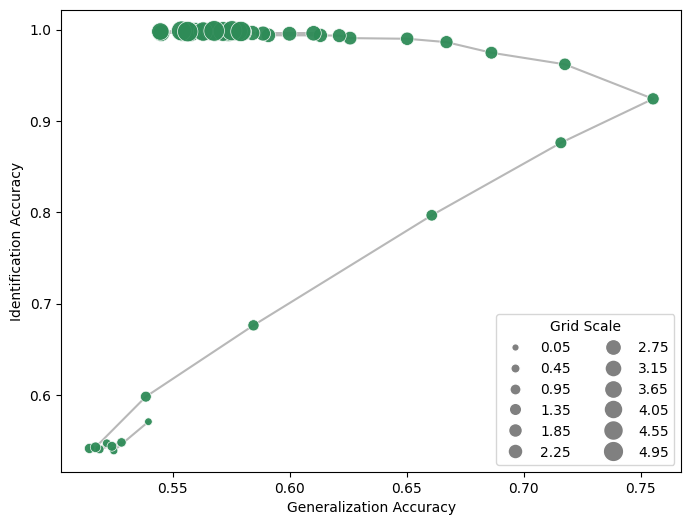

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# tensors -> numpy
gen = generalization.detach().cpu().numpy()      # [num_alphas, num_scales]
iden = identification.detach().cpu().numpy()
a_np = alphas.detach().cpu().numpy()             # [num_alphas]
s_np = scales.detach().cpu().numpy()             # [num_scales]

# pick the alpha row closest to 0
i0 = int(np.argmin(np.abs(a_np - 0.0)))
i0=0

# sort scales so points/line go left→right
s_order   = np.argsort(s_np)
s_sorted  = s_np[s_order]

# map scale → marker size
rng = np.ptp(s_sorted) + 1e-12
s_norm = (s_sorted - s_sorted.min()) / rng
size_min, size_max = 30.0, 220.0                      # scatter sizes are in pt^2
size_per_scale = size_min + (size_max - size_min) * s_norm

x = gen[i0, s_order]                                  # Generalization
y = iden[i0, s_order]                                 # Identification

plt.figure(figsize=(8, 6))

# gray connector line across scales
plt.plot(x, y, color='0.65', lw=1.5, alpha=0.8, zorder=1)

# scatter: size = scale; color is fixed since only one alpha
plt.scatter(
    x, y,
    s=size_per_scale,
    c='seagreen',               # or any single color you like
    edgecolors='white', linewidths=0.5,
    alpha=0.95, zorder=2
)

plt.xlabel('Generalization Accuracy')
plt.ylabel('Identification Accuracy')
#plt.title('ID vs Gen (α ≈ 0)\n(Size = Scale)')

# Legend: show "most" scales (up to 12, evenly spaced)
max_items = 12
if len(s_sorted) <= max_items:
    legend_scales = s_sorted
else:
    idxs = np.linspace(0, len(s_sorted)-1, max_items).round().astype(int)
    legend_scales = s_sorted[idxs]

def scale_to_size(s):
    return size_min + (size_max - size_min) * ((s - s_sorted.min()) / (np.ptp(s_sorted) + 1e-12))

handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=np.sqrt(scale_to_size(s)),
           markerfacecolor='gray', markeredgecolor='white',
           label=f'{s:.2f}')
    for s in legend_scales
]
plt.legend(handles=handles, title='Grid Scale', loc='lower right', frameon=True, ncol=2)

#plt.tight_layout()
plt.show()

In [ ]:
scales[12]
generalization[1,14]

tensor(0.7134, device='cuda:0')

In [ ]:
# Generalization/Identification Tradeoff with sweeps over noise & alpha
# + 3D contour (noise x alpha -> performance) at scale=1.65
# + heatmaps of rank of scale=1.65 vs all other scales for each (noise, alpha)

# Generalization/Identification vs noise & alpha, with continuous 3D contours
# and rank heatmaps (rank 1 = brightest). Pure NumPy + Matplotlib.

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Tuning (raise these for higher fidelity)
# =========================
Xmax        = 30        # lattice goes 0..Xmax in each dim (grid size = (Xmax+1)^2)
num_trials  = 2000      # pairs/samples per condition
sigma       = 0.1       # spread for the Gaussian part of transition
N_mod_1d    = 5         # number of modules (per the grid-code generator)
NperMod     = 9         # phases per module (must be a perfect square)
rng         = np.random.default_rng(123)

# Scales to compare; must include 1.65 for the requested plots
# (You can switch to np.arange(0.05, 5.01, 0.20) once performance is OK.)
scales      = np.unique(np.concatenate([np.arange(0.25, 3.51, 0.40), np.array([1.65])]))
alphas      = np.linspace(0.0, 1.0, 11)
noise_levels= np.linspace(0.0, 1.0, 21)

# =========================
# Helpers
# =========================
def sample_transition(space_points, centers, sigma, alpha, Xmax, rng):
    """
    Approximate sampling from (1-alpha)*Uniform + alpha*Normal(center, sigma^2 I),
    snapped to nearest integer grid point in [0..Xmax]^2.
    """
    T = centers.shape[0]
    M = space_points.shape[0]
    use_gauss = rng.random(T) < alpha
    out = np.empty_like(centers)

    if use_gauss.any():
        idx = np.where(use_gauss)[0]
        g = centers[idx] + rng.normal(0.0, sigma, size=(idx.size, 2))
        g = np.clip(np.rint(g), 0, Xmax).astype(int)
        out[idx] = g
    if (~use_gauss).any():
        idx = np.where(~use_gauss)[0]
        u_idx = rng.integers(0, M, size=idx.size)
        out[idx] = space_points[u_idx]
    return out

def points_to_grid_indices(pts, Xmax):
    x = np.clip(np.rint(pts[:,0]).astype(int), 0, Xmax)
    y = np.clip(np.rint(pts[:,1]).astype(int), 0, Xmax)
    return x, y

def hamming_distance_batch(a, b):
    return (a != b).mean(axis=1)

def euclid_closest(points, pair_points):
    d0 = np.linalg.norm(points - pair_points[:,0,:], axis=1)
    d1 = np.linalg.norm(points - pair_points[:,1,:], axis=1)
    return (d1 > d0).astype(int)  # 0 if closer to point 0, else 1

def build_grid_codes(Xmax, N_mod_1d, NperMod, scale, rng):
    """Binary grid codes on the whole lattice, shape [Xmax+1, Xmax+1, Features]."""
    n_side = int(np.sqrt(NperMod))
    assert n_side * n_side == NperMod, "NperMod must be a perfect square (e.g., 9,16)."

    # spatial lattice
    coords = np.arange(0, Xmax+1)
    Xg, Yg = np.meshgrid(coords, coords)
    XY = np.column_stack((Xg.ravel(), Yg.ravel())).astype(float)  # [(Xmax+1)^2, 2]

    # module frequencies (scaled)
    Fmods = np.zeros(N_mod_1d, dtype=np.float64)
    Fmods[0] = 0.0014
    for k in range(1, N_mod_1d):
        Fmods[k] = Fmods[k-1] * scale
    Fmods *= 2 * np.pi

    # basis directions (hex-like)
    b0 = np.array([1.0, 0.0])
    b1 = np.array([np.cos(np.pi/3),  np.sin(np.pi/3)])
    b2 = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])

    # offsets per module
    FAC = np.zeros(N_mod_1d, dtype=np.float64)
    FAC[0] = 0.06
    for k in range(1, N_mod_1d):
        FAC[k] = FAC[k-1] * scale

    GC_binary = np.zeros((Xmax+1, Xmax+1, NperMod, N_mod_1d), dtype=np.int8)
    for i_mod, F in enumerate(Fmods):
        fac = FAC[i_mod]
        for w in range(n_side):
            for j in range(n_side):
                ORI = rng.uniform(0, 2*np.pi)
                R = np.array([[np.cos(ORI), -np.sin(ORI)],
                              [np.sin(ORI),  np.cos(ORI)]])
                Off1 = R @ np.array([0, fac / F])
                Off2 = R @ np.array([fac * np.cos(np.pi/6) / F,
                                     fac * np.sin(np.pi/6) / F])
                Off  = (j / n_side) * Off1 + (w / n_side) * Off2

                z0 = (R @ b0).reshape(1,-1) * (F * XY + Off); z0 = z0.sum(axis=1)
                z1 = (R @ b1).reshape(1,-1) * (F * XY + Off); z1 = z1.sum(axis=1)
                z2 = (R @ b2).reshape(1,-1) * (F * XY + Off); z2 = z2.sum(axis=1)
                raw = np.cos(z0) + np.cos(z1) + np.cos(z2)
                bm = (raw >= 0).astype(np.int8)
                GC_binary[:, :, w*n_side + j, i_mod] = bm.reshape(Xmax+1, Xmax+1)
    return GC_binary.reshape(Xmax+1, Xmax+1, -1)  # [H, W, Features]

# =========================
# Simulation
# =========================
# lattice points
coords = np.arange(0, Xmax+1)
Xg, Yg = np.meshgrid(coords, coords)
space_points = np.column_stack((Xg.ravel(), Yg.ravel()))
M = space_points.shape[0]

# Pre-sample choice pairs once (reduce variance)
pair_idx = rng.integers(0, M, size=(num_trials, 2))
pairs = space_points[pair_idx]  # [T, 2, 2]

Gn, Ga, Gs = len(noise_levels), len(alphas), len(scales)
generalization_all = np.zeros((Gn, Ga, Gs), dtype=float)
identification_all = np.zeros((Gn, Ga, Gs), dtype=float)

# Precompute per-alpha generalization samples and which candidate is closest (Euclid)
alpha_gen_points = []
alpha_gen_closest = []
for alpha in alphas:
    centers = pairs[:, rng.integers(0,2,size=num_trials)]
    gen_pts = sample_transition(space_points, centers, sigma, alpha, Xmax, rng)
    alpha_gen_points.append(gen_pts)
    alpha_gen_closest.append(euclid_closest(gen_pts, pairs))

# Sweep scales outermost (so we build codes once per scale)
for si, scale in enumerate(scales):
    grid_codes = build_grid_codes(Xmax, N_mod_1d, NperMod, scale, rng)

    # codes for the two choice points
    p0x, p0y = points_to_grid_indices(pairs[:,0,:], Xmax)
    p1x, p1y = points_to_grid_indices(pairs[:,1,:], Xmax)
    p0_codes = grid_codes[p0x, p0y]        # [T, F]
    p1_codes = grid_codes[p1x, p1y]        # [T, F]

    base_id_a = hamming_distance_batch(p0_codes, p0_codes)   # zeros
    base_id_b = hamming_distance_batch(p1_codes, p0_codes)

    for ai, alpha in enumerate(alphas):
        gen_pts = alpha_gen_points[ai]
        gen_closest = alpha_gen_closest[ai]
        gx, gy = points_to_grid_indices(gen_pts, Xmax)
        gen_codes = grid_codes[gx, gy]

        base_gen_a = hamming_distance_batch(p0_codes, gen_codes)
        base_gen_b = hamming_distance_batch(p1_codes, gen_codes)

        for ni, noise in enumerate(noise_levels):
            # Generalization performance (Hamming + Gaussian noise)
            dist_a = base_gen_a + rng.normal(0, noise, size=num_trials)
            dist_b = base_gen_b + rng.normal(0, noise, size=num_trials)
            cond1 = (dist_a <  dist_b) & (gen_closest == 0)
            cond2 = (dist_a >  dist_b) & (gen_closest == 1)
            cond3 = (dist_a == dist_b) & (rng.standard_normal(num_trials) > 0)
            gen_perf = (cond1 | cond2 | cond3).mean()

            # Identification (target = p0)
            dist_id_a = base_id_a + rng.normal(0, noise, size=num_trials)
            dist_id_b = base_id_b + rng.normal(0, noise, size=num_trials)
            cond_id1 = (dist_id_a <  dist_id_b)
            cond_id3 = (dist_id_a == dist_id_b) & (rng.standard_normal(num_trials) > 0)
            id_perf = (cond_id1 | cond_id3).mean()

            generalization_all[ni, ai, si] = gen_perf
            identification_all[ni, ai, si] = id_perf

    print(f"scale={scale:.2f} done.")

# =========================
# Plots
# =========================
# 1) Continuous 3D filled contours (surfaces) for scale=1.65
si_target = int(np.argmin(np.abs(scales - 1.65)))
sc_target = float(scales[si_target])

NOISE, ALPHA = np.meshgrid(noise_levels, alphas, indexing='ij')
Z_gen = generalization_all[:, :, si_target]
Z_id  = identification_all[:, :, si_target]

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.contourf3D(NOISE, ALPHA, Z_gen, 40, antialiased=True)
ax1.set_title(f"Generalization (scale={sc_target:.2f})")
ax1.set_xlabel("Noise level"); ax1.set_ylabel("Alpha"); ax1.set_zlabel("Accuracy")

ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.contourf3D(NOISE, ALPHA, Z_id, 40, antialiased=True)
ax2.set_title(f"Identification (scale={sc_target:.2f})")
ax2.set_xlabel("Noise level"); ax2.set_ylabel("Alpha"); ax2.set_zlabel("Accuracy")
plt.tight_layout()
plt.show()

# 2) One 2D plot with BOTH metrics vs noise (alpha-averaged) for scale=1.65
gen_mean_alpha = Z_gen.mean(axis=1)
id_mean_alpha  = Z_id.mean(axis=1)

fig2, ax = plt.subplots(figsize=(7,5))
ax.plot(noise_levels, gen_mean_alpha, linewidth=2, label="Generalization (avg α)")
ax.set_xlabel("Noise level"); ax.set_ylabel("Generalization accuracy")
ax_t = ax.twinx()
ax_t.plot(noise_levels, id_mean_alpha, linewidth=2, linestyle='--', label="Identification (avg α)")
ax_t.set_ylabel("Identification accuracy")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_t.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="best")
plt.title(f"Performance vs Noise (scale={sc_target:.2f})")
plt.tight_layout()
plt.show()

# 3) Rank heatmaps of scale=1.65 across (noise, alpha) with INVERTED colors (rank 1 = brightest)
Gn, Ga, Gs = generalization_all.shape
rank_gen = np.zeros((Gn, Ga), dtype=int)
rank_id  = np.zeros((Gn, Ga), dtype=int)
for ni in range(Gn):
    for ai in range(Ga):
        order_gen = np.argsort(-generalization_all[ni, ai, :])  # descending perf
        order_id  = np.argsort(-identification_all[ni, ai, :])
        rank_gen[ni, ai] = int(np.where(order_gen == si_target)[0][0]) + 1
        rank_id[ni, ai]  = int(np.where(order_id  == si_target)[0][0]) + 1

fig3, axes = plt.subplots(1, 2, figsize=(12,5))
im0 = axes[0].imshow(rank_gen.T, origin='lower',
                     extent=[noise_levels.min(), noise_levels.max(), alphas.min(), alphas.max()],
                     aspect='auto', cmap='Greys_r')  # inverted: 1 is bright
axes[0].set_title(f"Rank of scale={sc_target:.2f} (Generalization)")
axes[0].set_xlabel("Noise level"); axes[0].set_ylabel("Alpha")
cbar0 = plt.colorbar(im0, ax=axes[0]); cbar0.set_label("Rank (1 = best)")

im1 = axes[1].imshow(rank_id.T, origin='lower',
                     extent=[noise_levels.min(), noise_levels.max(), alphas.min(), alphas.max()],
                     aspect='auto', cmap='Greys_r')
axes[1].set_title(f"Rank of scale={sc_target:.2f} (Identification)")
axes[1].set_xlabel("Noise level"); axes[1].set_ylabel("Alpha")
cbar1 = plt.colorbar(im1, ax=axes[1]); cbar1.set_label("Rank (1 = best)")
plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (186,2000,2) (186,2) 

Alpha=0.00 | Noise=0.00 | Scale=0.05 | Gen Acc=0.6207 | ID Acc=0.7587
Alpha=0.00 | Noise=0.00 | Scale=0.15 | Gen Acc=0.7979 | ID Acc=0.9541
Alpha=0.00 | Noise=0.00 | Scale=0.25 | Gen Acc=0.5594 | ID Acc=0.6332
Alpha=0.00 | Noise=0.00 | Scale=0.35 | Gen Acc=0.7548 | ID Acc=0.9388
Alpha=0.00 | Noise=0.00 | Scale=0.45 | Gen Acc=0.7153 | ID Acc=0.8920
Alpha=0.00 | Noise=0.00 | Scale=0.55 | Gen Acc=0.7389 | ID Acc=0.9206
Alpha=0.00 | Noise=0.00 | Scale=0.65 | Gen Acc=0.6914 | ID Acc=0.8677
Alpha=0.00 | Noise=0.00 | Scale=0.75 | Gen Acc=0.7520 | ID Acc=0.9547
Alpha=0.00 | Noise=0.00 | Scale=0.85 | Gen Acc=0.8177 | ID Acc=0.9830
Alpha=0.00 | Noise=0.00 | Scale=0.95 | Gen Acc=0.8378 | ID Acc=0.9923
Alpha=0.00 | Noise=0.00 | Scale=1.05 | Gen Acc=0.9206 | ID Acc=0.9990
Alpha=0.00 | Noise=0.00 | Scale=1.15 | Gen Acc=0.9327 | ID Acc=0.9997
Alpha=0.00 | Noise=0.00 | Scale=1.25 | Gen Acc=0.8755 | ID Acc=1.0000
Alpha=0.00 | Noise=0.00 | Scale=1.35 | Gen Acc=0.8142 | ID Acc=1.0000
Alpha=0.00 | Noise=0

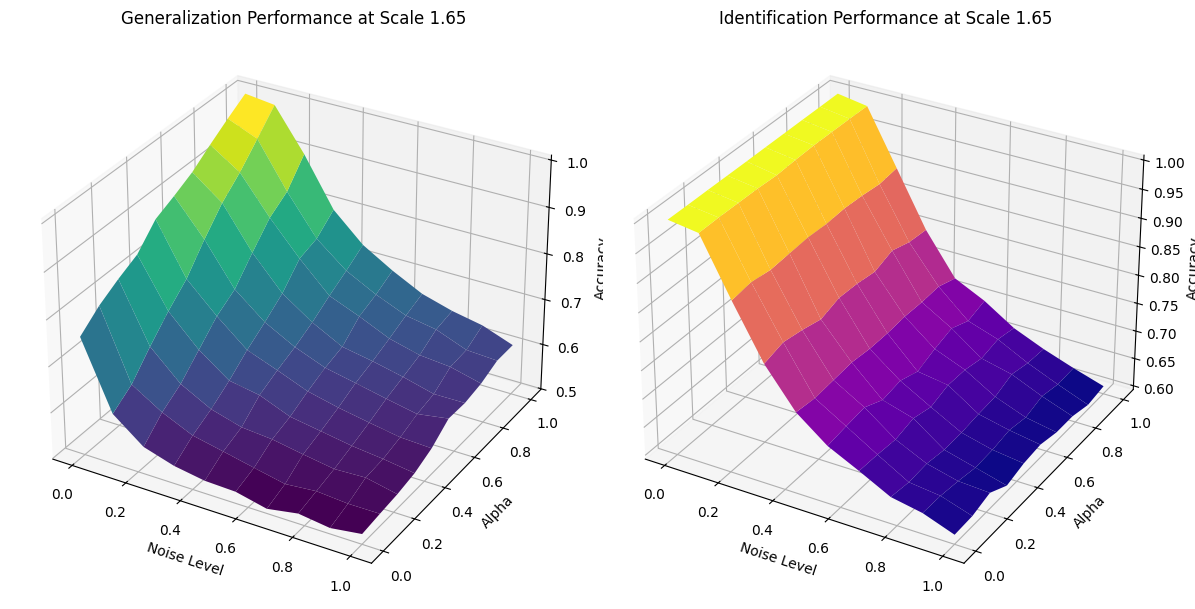

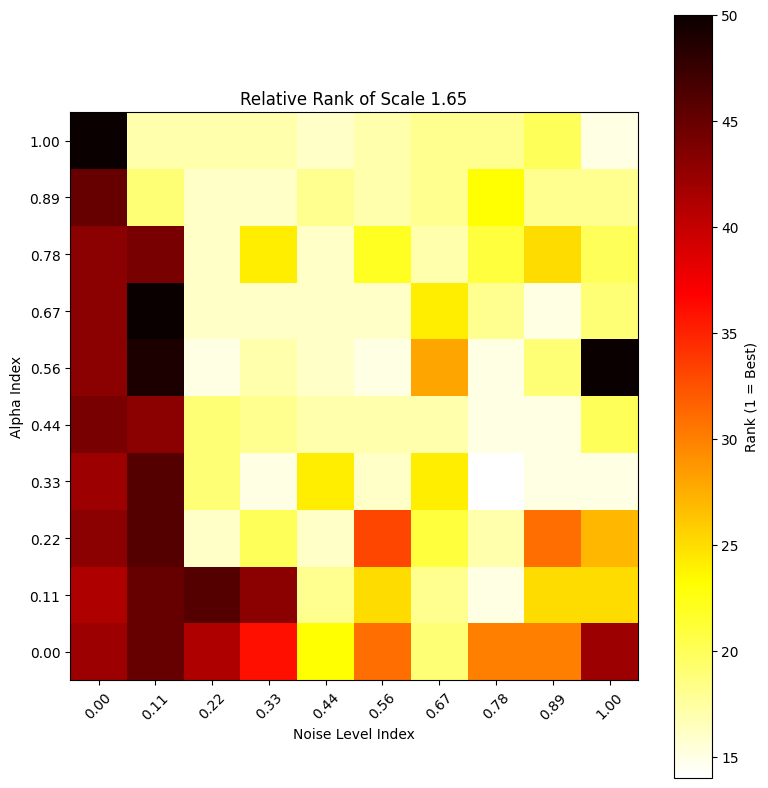

In [ ]:
# Generalization/Identification Tradeoff as a Function of Distribution Alignment

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Device
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------------------
# Helpers
# ----------------------------
def transition_distribution_2d(space_points, center_points, sigma, alpha):
    """
    space_points: [M, 2]  (torch, device)
    center_points: [num_trials, 2] (torch, device)
    sigma: float
    alpha: float in [0,1]
    Returns: probs of shape [num_trials, M] (torch, device)
    """
    num_trials = center_points.size(0)
    M = space_points.size(0)

    sp_exp = space_points.unsqueeze(0)      # [1, M, 2]
    cp_exp = center_points.unsqueeze(1)     # [num_trials, 1, 2]

    dists = torch.norm(sp_exp - cp_exp, dim=2)  # [num_trials, M]

    # Broadcast uniform across trials
    uniform = torch.ones(M, device=space_points.device) / M          # [M]
    gauss_unnorm = torch.exp(-(dists ** 2) / (2 * sigma ** 2))       # [num_trials, M]
    gauss = gauss_unnorm / gauss_unnorm.sum(dim=1, keepdim=True)     # [num_trials, M]

    probs = (1 - alpha) * uniform + alpha * gauss                  # [num_trials, M] via broadcast
    probs = probs / probs.sum(dim=1, keepdim=True)
    return probs

def points_to_grid_indices(pts, Xmax):
    """
    pts: [N, 2] torch on device
    Returns integer grid indices (x, y) clamped to [0, Xmax].
    """
    x = pts[:, 0].round().long().clamp(0, Xmax)
    y = pts[:, 1].round().long().clamp(0, Xmax)
    return x, y

def hamming_distance_batch(a, b):
    """
    a, b: torch tensors [B, D], same device, comparable dtype
    Returns mean Hamming distance across features for each batch item: [B]
    """
    return (a != b).to(torch.float32).mean(dim=1)

# ----------------------------
# Parameters
# ----------------------------
Xmax        = 100
num_trials  = 10000
sigma       = 0.1
N_mod_1d    = 13
nphase      = 10
nIT         = 10000

# sweep
scales = torch.arange(0.05, 5.0, 0.1, device=device)
alphas = torch.linspace(0.0, 1.0, 10, device=device)
noise_levels = torch.linspace(0.0, 1.0, 10, device=device)
target_scale = 1.65
target_scale_idx = torch.argmin(torch.abs(scales - target_scale))

# 2D space points for sampling (torch, device)
grid_points_1d = torch.linspace(0, Xmax, steps=100, device=device)
X_grid, Y_grid = torch.meshgrid(grid_points_1d, grid_points_1d, indexing='ij')
space_points = torch.stack([X_grid.reshape(-1), Y_grid.reshape(-1)], dim=1)  # [10000, 2]
M = space_points.size(0)

# Results (torch, device)
generalization = torch.zeros(len(alphas), len(noise_levels), len(scales), device=device)
identification = torch.zeros(len(alphas), len(noise_levels), len(scales), device=device)

# ----------------------------
# Main loops
# ----------------------------
alpha_ctr = -1
for alpha in alphas:
    alpha_ctr += 1
    noise_ctr = -1
    for noise_level in noise_levels:
        noise_ctr += 1
        scale_ctr = -1
        for scale in scales:
            scale_ctr += 1

            # ----------------------------
            # Build grid codes (NumPy) -> convert once to Torch(device)
            # ----------------------------
            scale_val = float(scale)  # use pure float in NumPy math
            Fmods = np.zeros(N_mod_1d, dtype=np.float64)
            Fmods[0] = 0.0014
            for k in range(1, N_mod_1d):
                Fmods[k] = Fmods[k-1] * scale_val
            Fmods *= 2 * np.pi

            NperMod = 16
            n_side  = int(np.sqrt(NperMod))
            if n_side * n_side != NperMod:
                raise ValueError("NperMod must be a perfect square")

            # spatial grid (NumPy)
            X = np.arange(0, Xmax+1)
            Y = X.copy()
            Xg, Yg = np.meshgrid(X, Y)
            XY = np.column_stack((Xg.ravel(), Yg.ravel()))  # [(Xmax+1)^2, 2]

            # basis directions
            b0 = np.array([1.0, 0.0])
            b1 = np.array([np.cos(np.pi/3),  np.sin(np.pi/3)])
            b2 = np.array([np.cos(2*np.pi/3), np.sin(2*np.pi/3)])

            # scaling factors for offsets
            FAC = np.zeros(N_mod_1d, dtype=np.float64)
            FAC[0] = 0.06
            for k in range(1, N_mod_1d):
                FAC[k] = FAC[k-1] * scale_val

            # allocate binary codes: (X, Y, phases, modules)
            GC_binary = np.zeros((Xmax+1, Xmax+1, NperMod, N_mod_1d), dtype=np.int8)

            # fill codes
            for i_mod, F in enumerate(Fmods):
                fac = FAC[i_mod]
                for w in range(n_side):
                    for j in range(n_side):
                        # random orientation per (module, phase)
                        ORI = np.random.uniform(0, 2*np.pi)
                        R = np.array([[np.cos(ORI), -np.sin(ORI)],
                                      [np.sin(ORI),  np.cos(ORI)]])

                        # two offset vectors
                        Off1 = R @ np.array([0, fac / F])
                        Off2 = R @ np.array([fac * np.cos(np.pi/6) / F,
                                             fac * np.sin(np.pi/6) / F])
                        Off  = (j / n_side) * Off1 + (w / n_side) * Off2

                        # raw sum of three cosines
                        z0 = ((R @ b0).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                        z1 = ((R @ b1).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                        z2 = ((R @ b2).reshape(1, -1) * (F * XY + Off)).sum(axis=1)
                        raw = np.cos(z0) + np.cos(z1) + np.cos(z2)

                        # threshold at zero -> balanced binary
                        bm = (raw >= 0).astype(np.int8)  # [ (Xmax+1)^2 ]
                        GC_binary[:, :, w*n_side + j, i_mod] = bm.reshape(Xmax+1, Xmax+1)

            # Convert to Torch on the chosen device and flatten feature dims only
            # Final shape: [Xmax+1, Xmax+1, N_mod_1d*NperMod]
            grid = torch.from_numpy(GC_binary).to(device=device)  # int8 on device
            grid = grid.view(Xmax+1, Xmax+1, -1)              # [Hx, Hy, nfeat]

            # ----------------------------
            # Sample pairs and generalization points (Torch, device)
            # ----------------------------
            sampled_pair_indices = torch.randint(0, M, (num_trials, 2), device=device)  # [num_trials, 2]
            sampled_pairs = space_points[sampled_pair_indices]                            # [num_trials, 2, 2]

            # --- Identification task ---
            target_choice = torch.randint(0, 2, (num_trials,), device=device)            # [num_trials]
            target_i = sampled_pairs[torch.arange(num_trials, device=device), target_choice]  # [num_trials, 2]
            dist_id = torch.norm(target_i.unsqueeze(1) - sampled_pairs, dim=2)           # [num_trials, 2]
            id_closest = torch.argmin(dist_id, dim=1)
            id_correct = (id_closest == target_choice).float()

            # --- Generalization task ---
            gaussian_centers = sampled_pairs[torch.arange(num_trials, device=device),
                                             torch.randint(0, 2, (num_trials,), device=device)]  # [num_trials, 2]
            gen_probs = transition_distribution_2d(space_points, gaussian_centers, sigma, float(alpha))  # [num_trials, M]
            gen_indices = torch.multinomial(gen_probs, 1).squeeze(1)                                    # [num_trials]
            gen_points = space_points[gen_indices]                                                      # [num_trials, 2]

            dist_gen = torch.norm(gen_points.unsqueeze(1) - sampled_pairs, dim=2)  # [num_trials, 2]
            gen_closest = torch.argmin(dist_gen, dim=1)
            gen_correct = (gen_closest == 0).float()  # example rule

            # ----------------------------
            # Extract grid codes using Torch indices (same device)
            # grid shape: [Xmax+1, Xmax+1, nfeat]
            # ----------------------------
            gen_x, gen_y = points_to_grid_indices(gen_points, Xmax)
            p0_x,  p0_y  = points_to_grid_indices(sampled_pairs[:, 0, :], Xmax)
            p1_x,  p1_y  = points_to_grid_indices(sampled_pairs[:, 1, :], Xmax)

            gen_codes = grid[gen_x, gen_y]          # [num_trials, nfeat]
            p0_codes  = grid[p0_x,  p0_y]           # [num_trials, nfeat]
            p1_codes  = grid[p1_x,  p1_y]           # [num_trials, nfeat]

            # ----------------------------
            # Hamming distances (Torch, device)
            # ----------------------------
            noise_a = torch.randn(num_trials, device=device) * noise_level
            noise_b = torch.randn(num_trials, device=device) * noise_level

            dist_a = hamming_distance_batch(p0_codes, gen_codes) + noise_a
            dist_b = hamming_distance_batch(p1_codes, gen_codes) + noise_b

            cond1 = (dist_a <  dist_b) & (gen_closest == 0)
            cond2 = (dist_a >  dist_b) & (gen_closest == 1)
            cond3 = (dist_a == dist_b) & (torch.randn(num_trials, device=device) > 0)
            gen_perf = (cond1 | cond2 | cond3).float()

            # Identification distances (using p0 as target)
            noise_id_a = torch.randn(num_trials, device=device) * noise_level
            noise_id_b = torch.randn(num_trials, device=device) * noise_level
            dist_id_a = hamming_distance_batch(p0_codes, p0_codes) + noise_id_a
            dist_id_b = hamming_distance_batch(p1_codes, p0_codes) + noise_id_b

            cond_id1 = (dist_id_a <  dist_id_b)
            cond_id3 = (dist_id_a == dist_id_b) & (torch.randn(num_trials, device=device) > 0)
            id_perf_final = (cond_id1 | cond_id3).float()

            # ----------------------------
            # Log & store
            # ----------------------------
            print(f"Alpha={float(alpha):.2f} | Noise={float(noise_level):.2f} | Scale={float(scale):.2f} | "
                  f"Gen Acc={gen_perf.mean().item():.4f} | ID Acc={id_perf_final.mean().item():.4f}")

            generalization[alpha_ctr, noise_ctr, scale_ctr] = gen_perf.mean()
            identification[alpha_ctr, noise_ctr, scale_ctr] = id_perf_final.mean()

# ----------------------------
# Plotting
# ----------------------------

## 3D Contour Plot for a fixed scale
target_scale_performance_gen = generalization[:, :, target_scale_idx].cpu().numpy()
target_scale_performance_id = identification[:, :, target_scale_idx].cpu().numpy()

# Create meshgrids for plotting
X_plot, Y_plot = np.meshgrid(noise_levels.cpu().numpy(), alphas.cpu().numpy())

fig = plt.figure(figsize=(12, 6))

# Generalization Performance Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title(f'Generalization Performance at Scale {target_scale:.2f}')
ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Alpha')
ax1.set_zlabel('Accuracy')
ax1.plot_surface(X_plot, Y_plot, target_scale_performance_gen, cmap='viridis')

# Identification Performance Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title(f'Identification Performance at Scale {target_scale:.2f}')
ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Alpha')
ax2.set_zlabel('Accuracy')
ax2.plot_surface(X_plot, Y_plot, target_scale_performance_id, cmap='plasma')

plt.tight_layout()
plt.show()


## Matrix Image for Ranking
# Calculate the ranking of the target scale (1.65)
# This finds the rank of the target scale's performance relative to all other scales
# A lower rank value is better. For example, rank 1 means it's the best.
combined_performance = generalization + identification
target_performance = combined_performance[:, :, target_scale_idx].unsqueeze(-1)
ranks = (combined_performance <= target_performance).sum(dim=2).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(ranks, cmap='hot_r', interpolation='nearest', origin='lower')
plt.colorbar(label='Rank (1 = Best)')
plt.title(f'Relative Rank of Scale {target_scale:.2f}')
plt.xlabel('Noise Level Index')
plt.ylabel('Alpha Index')
plt.xticks(np.arange(len(noise_levels)), [f'{n:.2f}' for n in noise_levels.cpu().numpy()], rotation=45)
plt.yticks(np.arange(len(alphas)), [f'{a:.2f}' for a in alphas.cpu().numpy()])
plt.tight_layout()
plt.show()

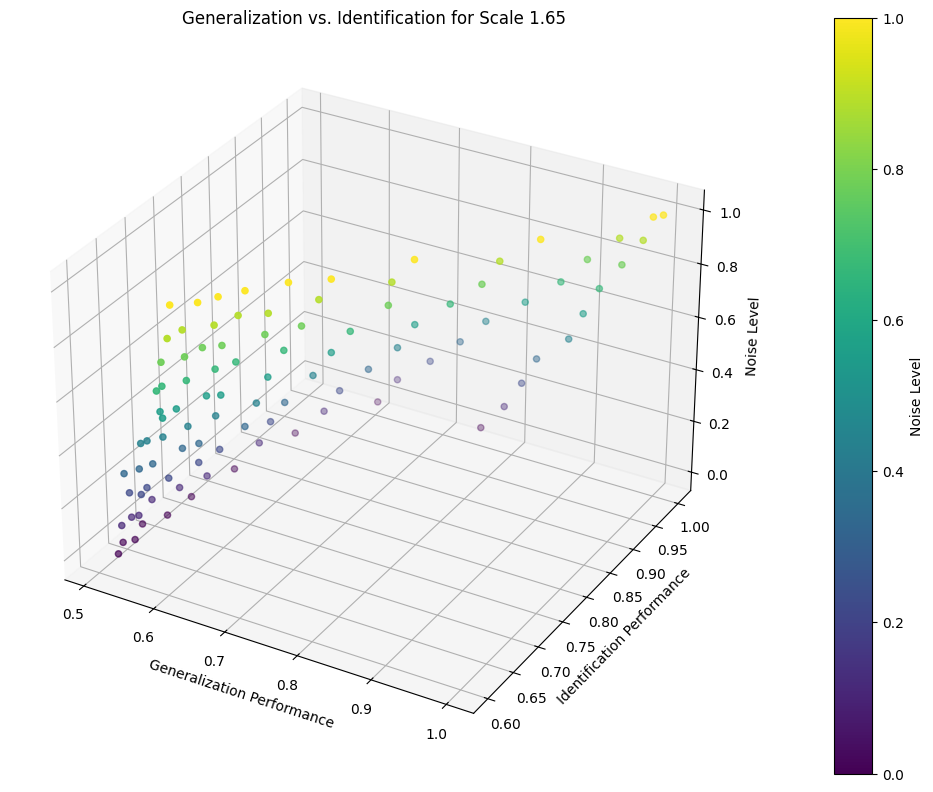

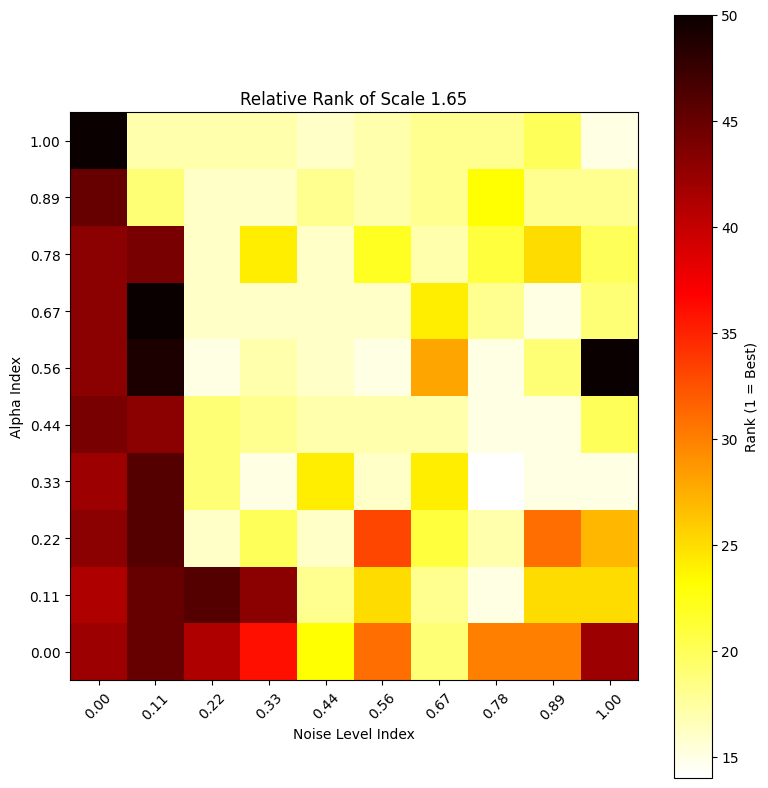

In [ ]:

## 3D Contour Plot for a fixed scale
# Select data for the target scale
gen_perf_for_scale = generalization[:, :, target_scale_idx].cpu().numpy().flatten()
id_perf_for_scale = identification[:, :, target_scale_idx].cpu().numpy().flatten()

# Create a flattened array of noise levels corresponding to each data point
noise_levels_flat = np.repeat(noise_levels.cpu().numpy(), len(alphas))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot where x=generalization, y=identification, z=noise_level
scatter = ax.scatter(gen_perf_for_scale, id_perf_for_scale, noise_levels_flat, c=noise_levels_flat, cmap='viridis')

ax.set_title(f'Generalization vs. Identification for Scale {target_scale:.2f}')
ax.set_xlabel('Generalization Performance')
ax.set_ylabel('Identification Performance')
ax.set_zlabel('Noise Level')

# Add a color bar to explain the colors of the points
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Noise Level')

plt.tight_layout()
plt.show()


## Matrix Image for Ranking
# Calculate the ranking of the target scale (1.65)
# This finds the rank of the target scale's performance relative to all other scales
# A lower rank value is better. For example, rank 1 means it's the best.
combined_performance = generalization + identification
target_performance = combined_performance[:, :, target_scale_idx].unsqueeze(-1)
ranks = (combined_performance <= target_performance).sum(dim=2).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(ranks, cmap='hot_r', interpolation='nearest', origin='lower')
plt.colorbar(label='Rank (1 = Best)')
plt.title(f'Relative Rank of Scale {target_scale:.2f}')
plt.xlabel('Noise Level Index')
plt.ylabel('Alpha Index')
plt.xticks(np.arange(len(noise_levels)), [f'{n:.2f}' for n in noise_levels.cpu().numpy()], rotation=45)
plt.yticks(np.arange(len(alphas)), [f'{a:.2f}' for a in alphas.cpu().numpy()])
plt.tight_layout()
plt.show()








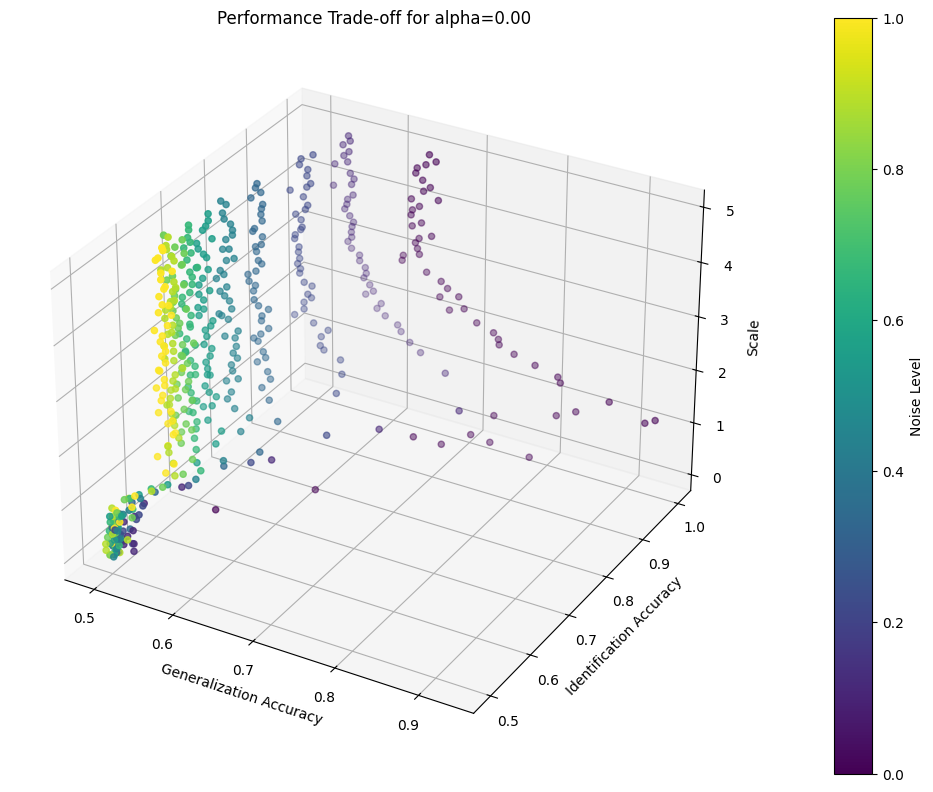

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'generalization', 'identification', 'scales', 'noise_levels',
# and 'alphas' are already populated from the main loops.

# ----------------------------
# Plotting
# ----------------------------

## 3D Plot for alpha=0
# Find the index for alpha=0
alpha_0_idx = torch.argmin(torch.abs(alphas - 0.0))

# Extract the data for this specific alpha value
gen_alpha_0 = generalization[alpha_0_idx, :, :].cpu().numpy().flatten()
id_alpha_0 = identification[alpha_0_idx, :, :].cpu().numpy().flatten()

# Create flattened arrays for x, y, and z axes
scales_flat = np.tile(scales.cpu().numpy(), len(noise_levels))
noise_levels_flat = np.repeat(noise_levels.cpu().numpy(), len(scales))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot with noise as the color
# x=generalization, y=identification, z=scale, color=noise_level
scatter = ax.scatter(gen_alpha_0, id_alpha_0, scales_flat, c=noise_levels_flat, cmap='viridis')

ax.set_title(f'Performance Trade-off for alpha={alphas[alpha_0_idx].item():.2f}')
ax.set_xlabel('Generalization Accuracy')
ax.set_ylabel('Identification Accuracy')
ax.set_zlabel('Scale')

# Add a color bar to explain the colors of the points
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Noise Level')

plt.tight_layout()
plt.show()

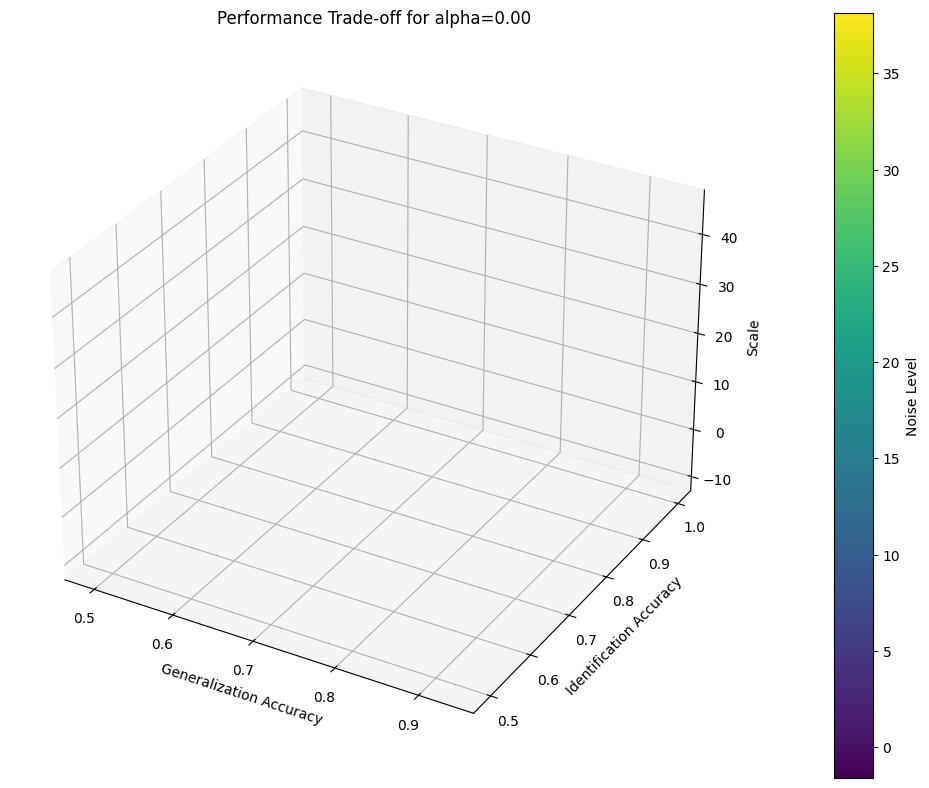

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# Assuming 'generalization', 'identification', 'scales', 'noise_levels',
# and 'alphas' are already populated from the main loops.

# ----------------------------
# Plotting
# ----------------------------

## 3D Surface Plot for alpha=0
# Find the index for alpha=0
alpha_0_idx = torch.argmin(torch.abs(alphas - 0.0))

# Extract the data for this specific alpha value
gen_alpha_0 = generalization[alpha_0_idx, :, :].cpu().numpy().flatten()
id_alpha_0 = identification[alpha_0_idx, :, :].cpu().numpy().flatten()

# Create flattened arrays for x, y, and z axes
scales_flat = np.tile(scales.cpu().numpy(), len(noise_levels))
noise_levels_flat = np.repeat(noise_levels.cpu().numpy(), len(scales))

# Create a grid for interpolation
# The interpolation will be on the generalization (x) and identification (y) plane.
# The z-axis will represent the scale.
xi, yi = np.meshgrid(np.linspace(min(gen_alpha_0), max(gen_alpha_0), 100),
                     np.linspace(min(id_alpha_0), max(id_alpha_0), 100))

# Interpolate the scale data onto the new grid
zi_scale = griddata((gen_alpha_0, id_alpha_0), scales_flat, (xi, yi), method='cubic')

# Interpolate the noise level data onto the new grid for coloring the surface
ci_noise = griddata((gen_alpha_0, id_alpha_0), noise_levels_flat, (xi, yi), method='cubic')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the surface plot
# x=generalization, y=identification, z=scale, color=noise_level
surface = ax.plot_surface(xi, yi, zi_scale, facecolors=plt.cm.viridis(ci_noise / np.max(ci_noise)), cmap='viridis')

ax.set_title(f'Performance Trade-off for alpha={alphas[alpha_0_idx].item():.2f}')
ax.set_xlabel('Generalization Accuracy')
ax.set_ylabel('Identification Accuracy')
ax.set_zlabel('Scale')

# Add a color bar to explain the colors of the points
mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(ci_noise)
cbar = fig.colorbar(mappable, ax=ax, pad=0.1)
cbar.set_label('Noise Level')

plt.tight_layout()
plt.show()